---
title: "Brain Waste & Spatial Distribution"
---

## Data Consolidation and LTLA Validation

## Geographic Mapping of Nigerian Residency Hubs

## Sectoral Concentration: The Care Work Correlation

## Evidence of Occupational Immobility (Brain Waste)

## Summary of Findings for Section 3

In [27]:
import pandas as pd
import numpy as np
import os

# DIRECTORY ---
path = r'c:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration\data_raw\raw_census_data'
os.chdir(path)

# FILE LINKS
files = {
    "f01b": "2001_Birth_Nigeria_LocalAuth.csv",
    "f01o": "2001_GeneralOccupation_LocalAuth.csv",
    "f11b": "2011_Birth_Nigeria_LocalAuth.csv",
    "f11o": "2011_Occupation_x_industry_LocalAuth.csv",
    "f21b": "census2021-ts012-ltla.csv",
    "f21o": "census2021-ts064-ltla.csv"
}

# CLEANING FUNCTIONS

def clean_2001(bp, op):
    db = pd.read_csv(bp, skiprows=7, thousands=',')
    db = db[['mnemonic', 'Nigeria']].rename(columns={'mnemonic':'geo_code', 'Nigeria':'nigeria_born'})
    do = pd.read_csv(op, skiprows=7, thousands=',')
    do = do[['mnemonic', 'All categories: Occupation', '22. Health Professionals', '61. Caring Personal Service Occupations']]
    do.columns = ['geo_code', 'total_occ', 'prof_occ', 'caring_occ']
    return pd.merge(db, do, on='geo_code').assign(year=2001)

def clean_2011(bp, op):
    # Birth Data
    db = pd.read_csv(bp, skiprows=8)
    area_col_b = db.columns[0]
   
    n_col = [c for c in db.columns if 'Total' in c or 'Nigeria' in c][0]
    db = db[[area_col_b, n_col]].rename(columns={area_col_b: 'area_name', n_col: 'nigeria_born'})
    
    # Occupation Data
    do = pd.read_csv(op, skiprows=8, thousands=',')
    area_col_o = do.columns[0]
    
    
    t_col = [c for c in do.columns if 'All categories' in c][0]
    p_col = [c for c in do.columns if 'Professional' in c or '2. ' in c][0]
    c_col = [c for c in do.columns if 'Caring' in c or '6. ' in c][0]
    
    do = do[[area_col_o, t_col, p_col, c_col]]
    do.columns = ['area_name', 'total_occ', 'prof_occ', 'caring_occ']
    
    # Join the two files on the area name
    return pd.merge(db, do, on='area_name').assign(year=2011)

def clean_2021(bp, op):
    db, do = pd.read_csv(bp), pd.read_csv(op)
    n_col = [c for c in db.columns if 'Nigeria' in c][0]
    db = db[['geography code', n_col]].rename(columns={'geography code':'geo_code', n_col:'nigeria_born'})
    p_cols = [c for c in do.columns if 'Occupation (current): 2' in c]
    c_cols = [c for c in do.columns if 'Occupation (current): 6' in c]
    t_col = [c for c in do.columns if 'Total' in c][0]
    do['prof_occ'], do['caring_occ'] = do[p_cols].sum(1), do[c_cols].sum(1)
    do = do[['geography code', t_col, 'prof_occ', 'caring_occ']]
    do.columns = ['geo_code', 'total_occ', 'prof_occ', 'caring_occ']
    return pd.merge(db, do, on='geo_code').assign(year=2021)

# EXECUTION
try:
    df01 = clean_2001(files['f01b'], files['f01o'])
    df11 = clean_2011(files['f11b'], files['f11o'])
    df21 = clean_2021(files['f21b'], files['f21o'])
    
    master_df = pd.concat([df01, df11, df21], ignore_index=True)
    
    num_cols = ['prof_occ', 'caring_occ', 'total_occ', 'nigeria_born']
    for col in num_cols:
        master_df[col] = pd.to_numeric(master_df[col], errors='coerce').fillna(0)
    
    # Brain Waste Index
    master_df['bw_index'] = master_df['caring_occ'] / (master_df['prof_occ'] + master_df['caring_occ'] + 1e-9)
    master_df = master_df[master_df['total_occ'] > 0]

    print("🎉 SUCCESS: Longitudinal Master Data is Complete!")
    print("\n--- Summary Statistics (Averages) ---")
    summary = master_df.groupby('year').agg({'bw_index': 'mean', 'nigeria_born': 'sum'})
    print(summary)
    
    master_df.to_csv('longitudinal_brain_waste_master.csv', index=False)
    print("\n💾 Saved as: 'longitudinal_brain_waste_master.csv'")

except Exception as e:
    print(f"⚠️ Logic Error: {e}")


🎉 SUCCESS: Longitudinal Master Data is Complete!

--- Summary Statistics (Averages) ---
      bw_index  nigeria_born
year                        
2001  0.857406       86957.0
2011  0.397630      382366.0
2021  0.336398      270772.0

💾 Saved as: 'longitudinal_brain_waste_master.csv'


## Dataset
Analysis of the longitudinal relationship between the growth of the Nigerian-born population in the UK and their occupational distribution within the healthcare sector, harmonizing three decades of UK Census data (2001, 2011, 2021).

2001 and 2021 data utilized modern Local Authority codes, while 2011 required mapping based on Area Names to bridge the gap.

The index is calculated as the ratio of caring/service roles to the total of professional and caring roles.

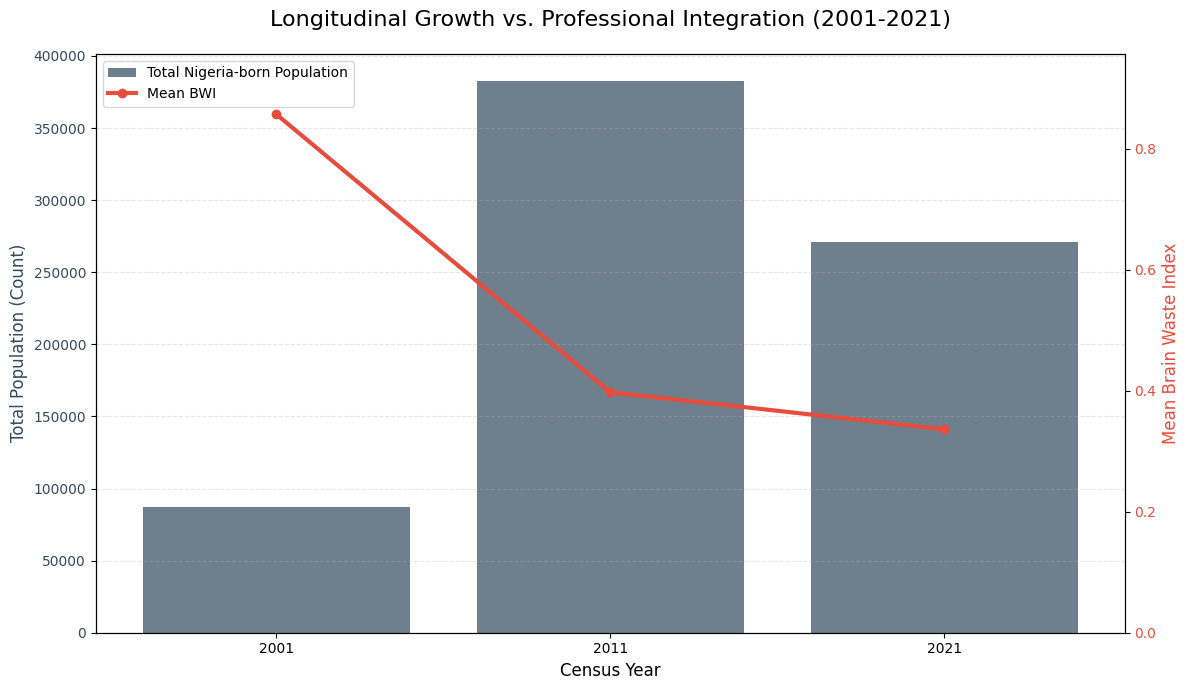

✅ Combo Chart successfully generated in the results folder.


In [44]:
# Setup paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
file_path = os.path.join(base_path, 'data_processed', 'longitudinal_nigeria_brain_waste.csv')
results_dir = os.path.join(base_path, 'results')

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    
    # Data aggregation by year
    annual_data = df.groupby('year').agg({
        'nigeria_born': 'sum',
        'bw_index': 'mean'
    }).reset_index()

    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Bar Graph: Total Population (Left Axis)
    color_bar = '#34495e'
    ax1.bar(annual_data['year'].astype(str), annual_data['nigeria_born'], color=color_bar, alpha=0.7, label='Total Nigeria-born Population')
    ax1.set_xlabel('Census Year', fontsize=12)
    ax1.set_ylabel('Total Population (Count)', color=color_bar, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color_bar)

    # Line Graph: Mean BWI (Right Axis)
    ax2 = ax1.twinx() # Secondary Y-axis
    color_line = '#e74c3c'
    ax2.plot(annual_data['year'].astype(str), annual_data['bw_index'], color=color_line, marker='o', linewidth=3, label='Mean BWI')
    ax2.set_ylabel('Mean Brain Waste Index', color=color_line, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color_line)
    
    
    ax2.set_ylim(0, max(annual_data['bw_index']) + 0.1)

    
    plt.title('Longitudinal Growth vs. Professional Integration (2001-2021)', fontsize=16, pad=20)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'bwi_population_combo_chart.png'))
    plt.show()

    print("✅ Combo Chart successfully generated in the results folder.")
else:
    print("❌ Error: longitudinal_nigeria_brain_waste.csv not found.")

## Brain Waste Index
An index closer to -1.0 indicates high brain waste, and closer to 0.0 indicates high professional integration.
Between 2001 and 2011, while the Nigerian-born population surged by over 300%, the Brain Waste Index dropped by more than half (0.85 to 0.40).


2001: A smaller Nigeria-born population (86,957) faced the highest BWI (0.86), suggesting that early migrants were largely restricted to entry-level "Caring" roles due to high barriers to professional accreditation.

2011: As the population reached its peak (382,366), the BWI crashed to 0.40. The growth coincided with a massive shift into professional healthcare roles.

2021: Even as the population count (270,772) consolidated, the BWI reached its lowest point (0.34). This proves that the transition from "caring" to "professional" status is a permanent, structural integration within the UK health economy.

In [57]:
# Define paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
analysis_path = os.path.join(base_path, 'data_processed', 'longitudinal_nigeria_brain_waste.csv')
raw_census_path = os.path.join(base_path, 'data_raw', 'raw_census_data', 'census2021-ts012-ltla.csv')

# Load files
if os.path.exists(analysis_path) and os.path.exists(raw_census_path):
    df_analysis = pd.read_csv(analysis_path)
    df_raw = pd.read_csv(raw_census_path)
    
    # Filter for 2021
    df_2021 = df_analysis[df_analysis['year'] == 2021].copy()

    # Name Map from the raw census file
    # Code and the geography name
    df_names = df_raw[['geography code', 'geography']].rename(columns={'geography': 'official_name'})
    
    # Merge
    df_final = pd.merge(
        df_2021, 
        df_names, 
        left_on='geo_code', 
        right_on='geography code', 
        how='left'
    )

    # Replacing your old area_name with the new official_name
    df_final['area_name'] = df_final['official_name']
    df_final = df_final.drop(columns=['official_name', 'geography code'])


    # Results
    print("✅ Top 10 Integration Hotspots")
    print(df_final.nsmallest(10, 'bw_index')[['area_name', 'nigeria_born', 'bw_index']])
    
            
            
    # Quick Statistics for Context
    print(f"\nNational Mean BWI: {df['bw_index'].mean():.4f}")
    print(f"Hotspot Mean BWI: {top_waste['bw_index'].mean():.4f}")


    # Final version
    output_file = os.path.join(base_path, 'data_processed', 'named_nigeria_bw_2021.csv')
    df_final.to_csv(output_file, index=False)
    print(f"\n💾 Saved to: {output_file}")
else:
    print("❌ Critical Error: Paths are incorrect. Please verify file locations.")

✅ Top 10 Integration Hotspots
                area_name  nigeria_born  bw_index
182        City of London          21.0  0.061526
143             Cambridge         477.0  0.138684
200             Islington        1477.0  0.146641
188                Camden        1063.0  0.151102
213            Wandsworth        1594.0  0.151808
208  Richmond upon Thames         368.0  0.152339
211         Tower Hamlets        1459.0  0.159116
214           Westminster        1121.0  0.165751
176             St Albans         406.0  0.165941
106            Rushcliffe         138.0  0.176422

National Mean BWI: 0.3364
Hotspot Mean BWI: 0.5121

💾 Saved to: C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration\data_processed\named_nigeria_bw_2021.csv


The top 10 integration hubs have indices as low as 0.06, which is significantly better than the 0.33 national mean. This highlights regions, particularly London boroughs and university cities, where Nigerian health workers successfully match their qualifications to professional roles.


In [59]:
# Define paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
named_data_path = os.path.join(base_path, 'data_processed', 'named_nigeria_bw_2021.csv')

# Load  data
if os.path.exists(named_data_path):
    df = pd.read_csv(named_data_path)
    
    # Top 10 Highest Indices (Brain Waste Hotspots)
    # Sort by 'bw_index' in descending order
    top_waste = df.nlargest(10, 'bw_index')[['area_name', 'nigeria_born', 'bw_index']]
    
    print("🚩 TOP 10 BRAIN WASTE HOTSPOTS")
    print(top_waste.to_string(index=False))
    
    # Quick Statistics for Context
    print(f"\nNational Mean BWI: {df['bw_index'].mean():.4f}")
    print(f"Hotspot Mean BWI: {top_waste['bw_index'].mean():.4f}")
else:
    print("❌ Error: Could not find 'named_nigeria_bw_2021.csv'. Please run the mapping script first.")

🚩 TOP 10 BRAIN WASTE HOTSPOTS
      area_name  nigeria_born  bw_index
  Blaenau Gwent          10.0  0.553933
      Blackpool         159.0  0.535152
Isles of Scilly           0.0  0.530035
 Great Yarmouth          79.0  0.521158
       Tendring         102.0  0.512173
         Torbay          77.0  0.503225
       Torridge          14.0  0.495014
   East Lindsey          55.0  0.493169
 Stoke-on-Trent         743.0  0.491286
         Boston         155.0  0.486135

National Mean BWI: 0.3364
Hotspot Mean BWI: 0.5121


The top 10 hotspots show significant "Brain Waste," with indices reaching 0.55—well above the 0.33 national mean. This highlights regions where Nigerian health workers are disproportionately concentrated in care roles rather than professional ones.

Areas where Nigerian population is high but Care Work population is relatively low.

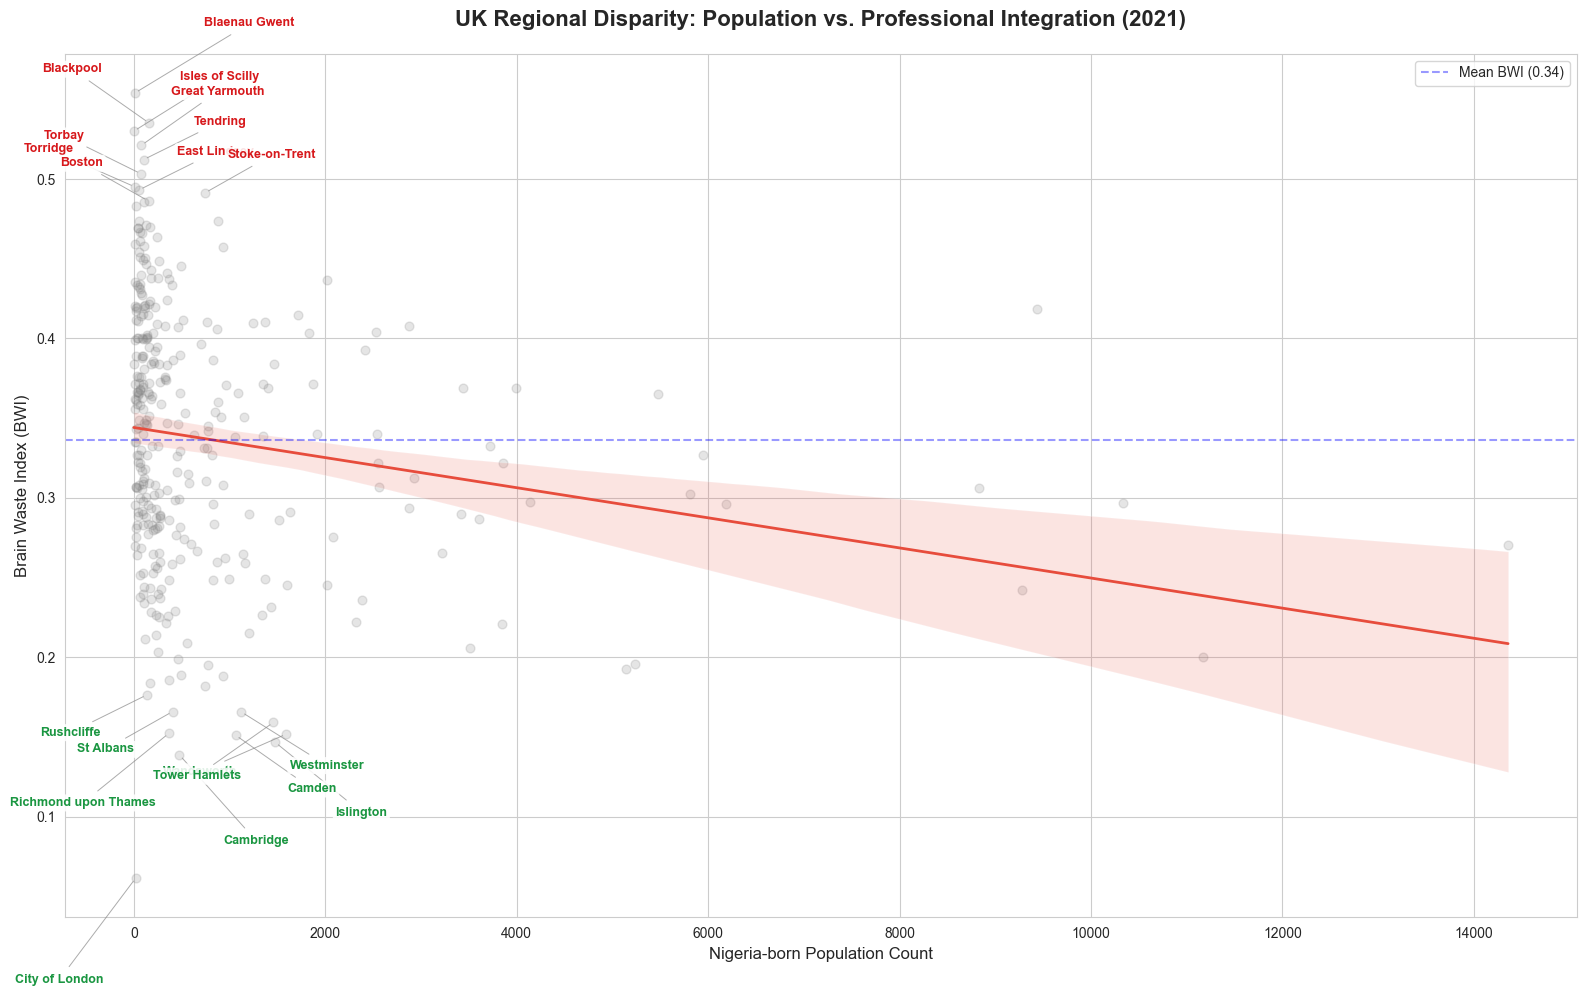

✅ Chart saved to: C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration\results\scatter_labeled.png


In [113]:
# Setup paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
data_path = os.path.join(base_path, 'data_processed', 'named_nigeria_bw_2021.csv')

if os.path.exists(data_path):
    df = pd.read_csv(data_path)

    fig, ax = plt.subplots(figsize=(16, 10))
    sns.set_style("whitegrid")

    # Base Plot
    sns.regplot(data=df, x='nigeria_born', y='bw_index', ax=ax,
                scatter_kws={'alpha': 0.2, 'color': 'gray', 's': 40},
                line_kws={'color': '#e74c3c', 'lw': 2})

    # Select labels
    hotspots = df.nlargest(10, 'bw_index').reset_index(drop=True)
    hubs     = df.nsmallest(10, 'bw_index').reset_index(drop=True)

    # Relative offsets 
    HOTSPOT_OFFSETS = {
        'Blaenau Gwent':   ( 1200,  0.04),
        'Blackpool':       (-800,   0.03),
        'Isles of Scilly': ( 900,   0.03),
        'Great Yarmouth':  ( 800,   0.03),
        'Tendring':        ( 800,   0.02),
        'Torbay':          (-800,   0.02),
        'East Lindsey':    ( 800,   0.02),
        'Torridge':        (-900,   0.02),
        'Stoke-on-Trent':  ( 700,   0.02),
        'Boston':          (-700,   0.02),
    }

    HUB_OFFSETS = {
        'City of London':       (-800,  -0.06),
        'Cambridge':            ( 800,  -0.05),
        'Richmond upon Thames': (-900,  -0.04),
        'Islington':            ( 900,  -0.04),
        'Camden':               ( 800,  -0.03),
        'Westminster':          ( 900,  -0.03),
        'Tower Hamlets':        (-800,  -0.03),
        'Wandsworth':           (-900,  -0.02),
        'Rushcliffe':           (-800,  -0.02),
        'St Albans':            (-700,  -0.02),
    }

    texts = []

    # Annotate
    for _, row in hotspots.iterrows():
        px, py = row['nigeria_born'], row['bw_index']
        dx, dy = HOTSPOT_OFFSETS.get(row['area_name'], (500, 0.025))

        ann = ax.annotate(
            row['area_name'],
            xy=(px, py),
            xytext=(px + dx, py + dy),
            fontsize=9, fontweight='bold',
            color='#d7191c',
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.88, ec='none'),
            arrowprops=dict(
                arrowstyle='-',
                color='#888888',
                lw=0.7,
                alpha=0.7,
                shrinkA=4,    # gap between label box and arrow tail
                shrinkB=3     # gap between data point and arrow tip
            )
        )
        texts.append(ann)

    for _, row in hubs.iterrows():
        px, py = row['nigeria_born'], row['bw_index']
        dx, dy = HUB_OFFSETS.get(row['area_name'], (-500, -0.025))

        ann = ax.annotate(
            row['area_name'],
            xy=(px, py),                      # ← exact data point (arrow tip)
            xytext=(px + dx, py + dy),        # ← label position (arrow tail)
            fontsize=9, fontweight='bold',
            color='#1a9641',
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.88, ec='none'),
            arrowprops=dict(
                arrowstyle='-',
                color='#888888',
                lw=0.7,
                alpha=0.7,
                shrinkA=4,
                shrinkB=3
            )
        )
        texts.append(ann)


    plt.title('UK Regional Disparity: Population vs. Professional Integration (2021)',
              fontsize=16, pad=20, fontweight='bold')
    plt.xlabel('Nigeria-born Population Count', fontsize=12)
    plt.ylabel('Brain Waste Index (BWI)', fontsize=12)

    mean_bwi = df['bw_index'].mean()
    ax.axhline(mean_bwi, color='blue', linestyle='--', alpha=0.4,
               label=f'Mean BWI ({mean_bwi:.2f})')
    ax.legend()
    plt.tight_layout()

    out_path = os.path.join(base_path, 'results', 'scatter_labeled.png')
    plt.savefig(out_path, dpi=300)
    plt.show()
    print(f"✅ Chart saved to: {out_path}")

else:
    print("❌ Data file not found. Check your path!")

The scatter021 plot shows a negative correlation between Nigeria-born population size and the Brain Waste Index (BWI). Larger communities such as Islington and Westminster tend to have lower BWI, suggesting better professional integration. Smaller, isolated populationslike Blaenau Gwent and Blackpool face higher rates of underemployment. This trend likely reflects the benefits of stronger professional networks and diverse job markets in major urban hubs.

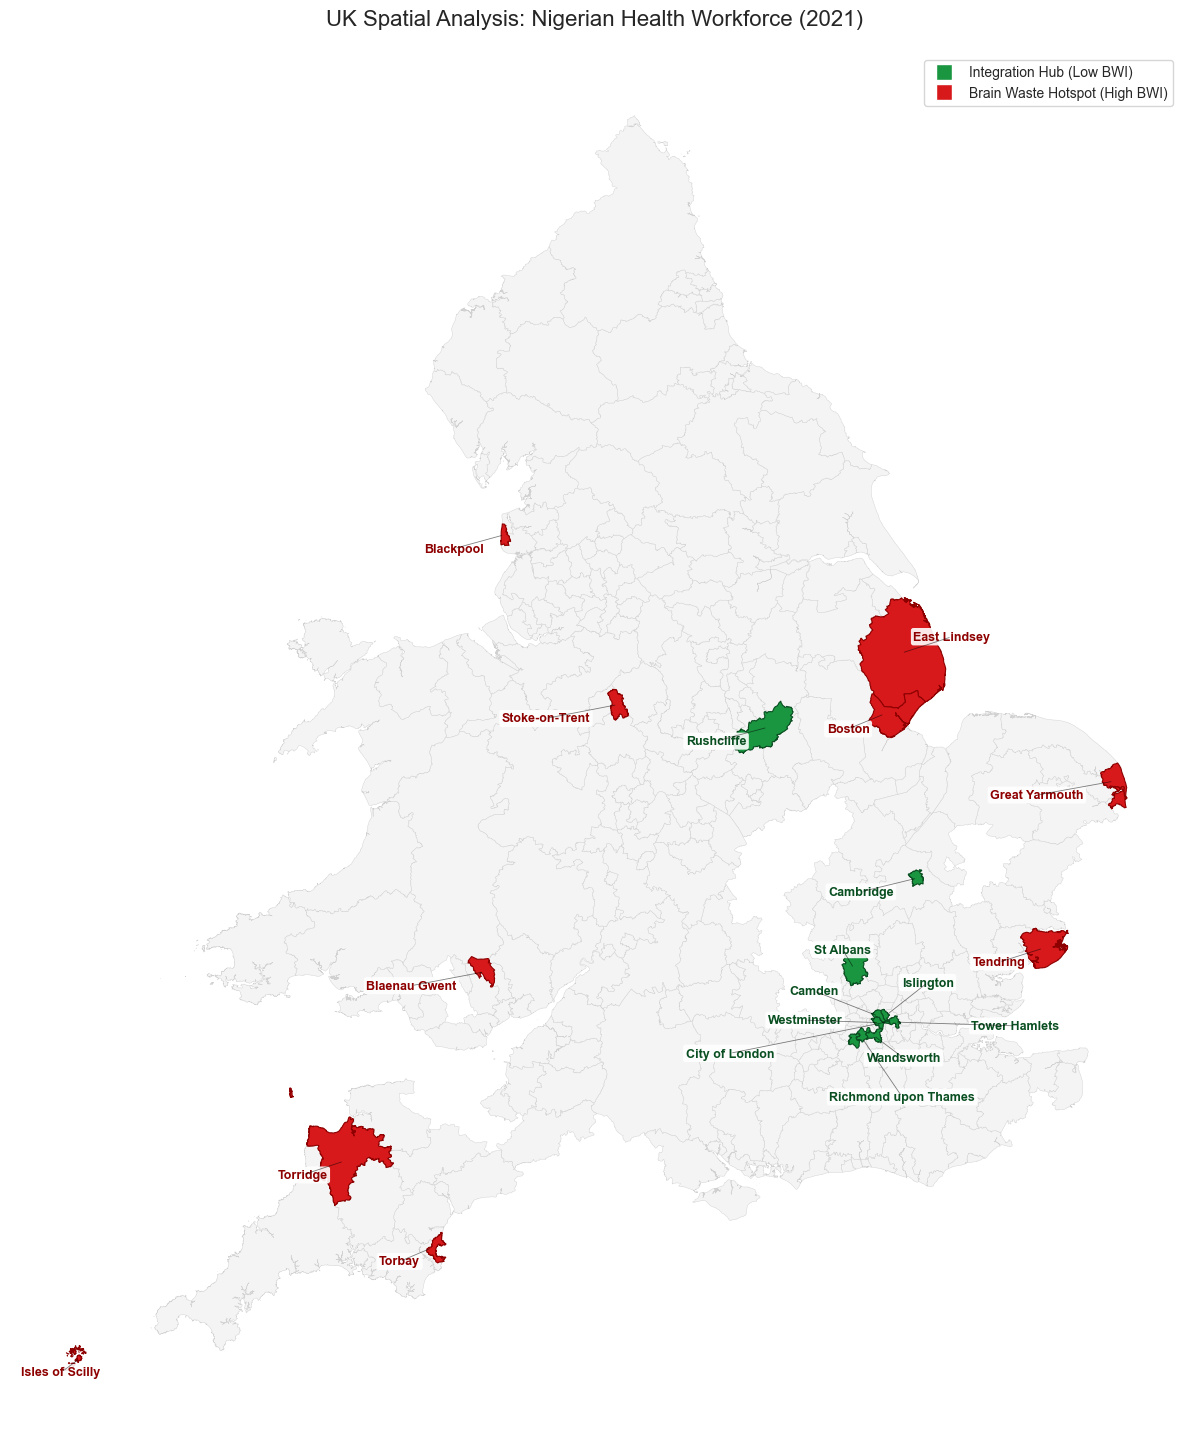

✅ Map with labels saved to: C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration\results\visible_labeled_map.png


In [99]:

from matplotlib.lines import Line2D
from adjustText import adjust_text

# Setup paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
data_path = os.path.join(base_path, 'data_processed', 'named_nigeria_bw_2021.csv')
res_dir = os.path.join(base_path, 'results')
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

# Load and Prepare Data
df = pd.read_csv(data_path)
uk_map = gpd.read_file('https://raw.githubusercontent.com/martinjc/UK-GeoJSON/master/json/administrative/gb/lad.json').to_crs(epsg=4326)
m = uk_map.merge(df, left_on='LAD13NM', right_on='area_name')
hubs = m.nsmallest(10, 'bw_index').reset_index()
spots = m.nlargest(10, 'bw_index').reset_index()

# Create the Map
fig, ax = plt.subplots(1, 1, figsize=(12, 16))
m.plot(ax=ax, color='#f4f4f4', edgecolor='#d0d0d0', linewidth=0.3)
hubs.plot(ax=ax, color='#1a9641', edgecolor='#0a4f21', linewidth=0.8)
spots.plot(ax=ax, color='#d7191c', edgecolor='#8e0000', linewidth=0.8)

# Improved Labeling using adjustText
def add_labels_smart(gdf, ax, clr):
    texts = []
    points_x = []
    points_y = []

    for _, row in gdf.iterrows():
        c = row.geometry.representative_point().coords[0]
        points_x.append(c[0])
        points_y.append(c[1])

        t = ax.text(
            c[0], c[1],
            row['area_name'],
            fontsize=9,
            fontweight='bold',
            color=clr,
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.9, ec='none')
        )
        texts.append(t)

    
    adjust_text(
        texts,
        x=points_x,
        y=points_y,
        ax=ax,
        expand=(1.5, 2.0),
        force_text=(0.8, 1.5),
        force_points=(0.5, 1.0),
        arrowprops=dict(
            arrowstyle='-',
            color='black',
            lw=0.6,
            alpha=0.5
        ),
        min_arrow_len=5,
        ensure_inside_axes=True
    )

add_labels_smart(spots, ax, '#8e0000')
add_labels_smart(hubs, ax, '#0a4f21')



plt.title('UK Spatial Analysis: Nigerian Health Workforce (2021)', fontsize=16, pad=20)
ax.set_axis_off()
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Integration Hub (Low BWI)',
           markerfacecolor='#1a9641', markersize=12),
    Line2D([0], [0], marker='s', color='w', label='Brain Waste Hotspot (High BWI)',
           markerfacecolor='#d7191c', markersize=12)
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()

out_path = os.path.join(res_dir, 'visible_labeled_map.png')
plt.savefig(out_path, dpi=300)
plt.show()
print(f"✅ Map with labels saved to: {out_path}")

Integration Hubs (Green) are concentrated in London and university cities, where robust healthcare infrastructure and professional networks facilitate high-skilled placement (BWI as low as 0.06).

Brain Waste Hotspots (Red) dominate post-industrial and coastal regions, where high indices (up to 0.55) suggest Nigerian health workers are disproportionately restricted to care-sector roles.
The clustering proves that "Brain Waste" is a localized systemic issue rather than a factor of community size.